In [1]:
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

In [2]:
kanser_verisi = load_breast_cancer()
df = pd.DataFrame(kanser_verisi.data, columns=kanser_verisi.feature_names)
df['Hedef'] = kanser_verisi.target

In [3]:
X = df.drop('Hedef', axis=1)
y = df['Hedef']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [4]:
nb_model = GaussianNB()

nb_model.fit(X_train, y_train)
tahminler_nb = nb_model.predict(X_test)

In [5]:
basari_nb = accuracy_score(y_test, tahminler_nb)
print(f"Naive Bayes Doğruluk Oranı: %{basari_nb * 100:.2f}")

Naive Bayes Doğruluk Oranı: %97.37


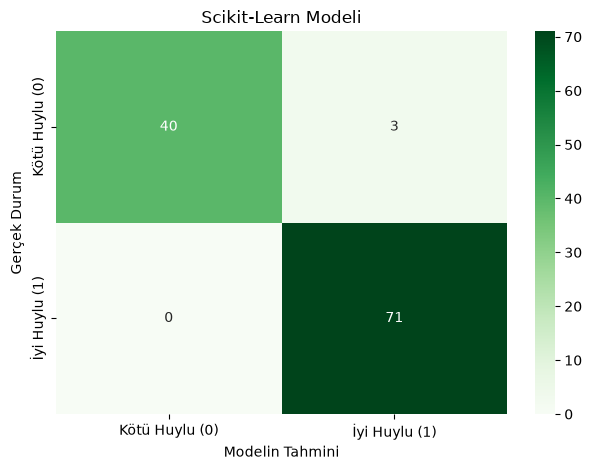

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm_sklearn = confusion_matrix(y_test, tahminler_nb.ravel())

ax = plt.axes()
sns.heatmap(cm_sklearn, annot=True, fmt='d', cmap='Greens', ax= ax, 
            xticklabels=['Kötü Huylu (0)', 'İyi Huylu (1)'], 
            yticklabels=['Kötü Huylu (0)', 'İyi Huylu (1)'])
ax.set_title('Scikit-Learn Modeli')
ax.set_xlabel('Modelin Tahmini')
ax.set_ylabel('Gerçek Durum')

plt.tight_layout()
plt.show()